In [ ]:
import time
from functools import partial
import matplotlib.pyplot as plt
import numpy as np
import jax
import jax.numpy as jnp
import optax

key = jax.random.PRNGKey(42)

## Hybrid Method: Euler Predictor + Neural Correction (JAX)

**Problem:** Solve $\dfrac{dy}{dx} = x$, $y(0) = 0$. Exact solution: $y(x) = \dfrac{x^2}{2}$.

**Method (Lecture 2, Slides 31–33):**

1. **Euler Predictor** – Run Euler's method with step $\Delta x$ to get a rough trajectory $y_{\text{Eu}}(x)$.
2. **Neural Correction** – Train a network $h_\theta(x)$ to learn the residual $y^*(x_k) - y_{\text{Eu}}(x_k)$, with an IC penalty $h_\theta(0)^2$.
3. **Hybrid solution** – $y(x) = y_{\text{Eu}}(x) + h_\theta(x)$.

**Loss (Slide 32):**
$$\mathcal{L}(\theta) = \sum_{k}\bigl(y^*_k - y_{\text{Eu}}(x_k) - h_\theta(x_k)\bigr)^2 + \bigl(h_\theta(0)\bigr)^2$$

**Inverse Problem** – We also jointly estimate the unknown coefficient $\alpha$ in $dy/dx = \alpha x$ from noisy data.

In [ ]:
# ── Exact solution ────────────────────────────────────────────────────────
def exact_solution(x):
    """Analytical answer: y = x^2 / 2  (integral of x)"""
    return x**2 / 2


# ── Neural network (fully-connected) ─
class FCN:
    @staticmethod
    def init_parameters(key, layer_sizes):
        """Xavier-style uniform initialisation for every layer."""
        keys = jax.random.split(key, len(layer_sizes) - 1)
        return [FCN._random_layer_parameters(k, m, n)
                for k, m, n in zip(keys, layer_sizes[:-1], layer_sizes[1:])]

    @staticmethod
    def _random_layer_parameters(key, m, n):
        W_key, b_key = jax.random.split(key)
        v = jnp.sqrt(1 / m)
        W = jax.random.uniform(W_key, (n, m), minval=-v, maxval=v)
        b = jax.random.uniform(b_key, (n,),   minval=-v, maxval=v)
        return W, b

    @staticmethod
    def forward(parameters, x):
        """Forward pass: tanh hidden layers, linear output."""
        for W, b in parameters[:-1]:
            x = jnp.tanh(jnp.dot(W, x) + b)
        W_last, b_last = parameters[-1]
        return jnp.dot(W_last, x) + b_last

## Step 1 – Euler Predictor

Apply Euler's method to $y' = x$:
$$y_{k+1} = y_k + \Delta x \cdot x_k$$
The result is a piecewise-linear trajectory $y_{\text{Eu}}$ stored on a NumPy grid.

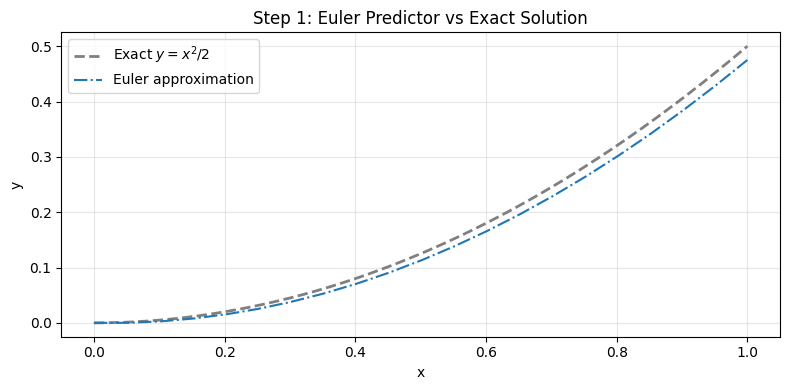

Euler MSE: 0.000204


In [ ]:
# ── Euler predictor (pure NumPy – no JAX needed for this step) ────────────
x0, x_end = 0.0, 1.0
y0        = 0.0
dt        = 0.05          # step size → 21 grid points

x_euler_np = np.arange(x0, x_end + dt, dt)
y_euler_np = np.zeros_like(x_euler_np)
y_euler_np[0] = y0

def F_rhs(x, y):
    """RHS of the ODE: dy/dx = x"""
    return x

for k in range(len(x_euler_np) - 1):
    y_euler_np[k + 1] = y_euler_np[k] + dt * F_rhs(x_euler_np[k], y_euler_np[k])


def y_euler_at(x_jnp):
    """Evaluate y_Eu at arbitrary JAX array x by linear interpolation."""
    x_np = np.array(x_jnp).flatten()
    y_np = np.interp(x_np, x_euler_np, y_euler_np)
    return jnp.array(y_np).reshape(-1, 1)


# ── Quick visual: Euler vs exact ──────────────────────────────────────────
x_test = jnp.linspace(x0, x_end, 300).reshape(-1, 1)
y_exact_test = jax.vmap(exact_solution)(x_test)
y_eu_test    = y_euler_at(x_test)

plt.figure(figsize=(8, 4))
plt.plot(x_test, y_exact_test, label='Exact $y=x^2/2$',       color='grey',      linestyle='--', lw=2)
plt.plot(x_test, y_eu_test,    label='Euler approximation',    color='tab:blue',  linestyle='-.',  lw=1.5)
plt.title('Step 1: Euler Predictor vs Exact Solution')
plt.xlabel('x'); plt.ylabel('y')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

euler_mse = float(jnp.mean((y_eu_test - y_exact_test)**2))
print(f'Euler MSE: {euler_mse:.6f}')

## Step 2 – Generate Measurements & Define Correction Network

We treat $y^*_k = y_{\text{exact}}(x_k) + \text{noise}$ as observations.  
The correction targets are: $r_k = y^*_k - y_{\text{Eu}}(x_k)$.

In [ ]:
# ── Measurements at Euler grid points ─────────────────────────────────────
key, subkey = jax.random.split(key)
x_meas = jnp.array(x_euler_np).reshape(-1, 1)                     # shape (21, 1)
y_star = exact_solution(x_meas) + 0.002 * jax.random.normal(subkey, x_meas.shape)

y_eu_meas = y_euler_at(x_meas)                                     # Euler values at grid
residuals  = y_star - y_eu_meas                                    # what h_theta must learn

print(f'Measurement points : {x_meas.shape[0]}')
print(f'Max |residual|     : {float(jnp.abs(residuals).max()):.5f}')

# ── Correction network ────────────────────────────────────────────────────
network      = FCN
key, subkey  = jax.random.split(key)
params_corr  = network.init_parameters(subkey, [1, 32, 32, 1])    # 1-in, 1-out, 2 hidden
optimiser_corr = optax.adam(learning_rate=1e-3)
opt_state_corr = optimiser_corr.init(params_corr)

print('Correction network ready.')

Measurement points : 21
Max |residual|     : 0.02446
Correction network ready.


## Step 3 – Train the Correction Network

Minimise the hybrid loss (Slide 32):
$$\mathcal{L}(\theta) = \underbrace{\frac{1}{n}\sum_k\bigl(r_k - h_\theta(x_k)\bigr)^2}_{\text{residual fit}} + \underbrace{h_\theta(0)^2}_{\text{IC penalty}}$$

In [ ]:
# ── Network forward for a single point (scalar input) ─────────────────────
def h_single(params, x_scalar):
    """Evaluate h_theta at a single x value (shape () or (1,))."""
    return network.forward(params, x_scalar.reshape(1,)).squeeze()


# ── Hybrid loss ───────────────────────────────────────────────────────────
def hybrid_loss(params, x_meas, residuals):
    """
    params    : correction network weights
    x_meas    : (n,1) measurement x-locations
    residuals : (n,1) targets  r_k = y*_k - y_Eu(x_k)
    """
    # Vectorise over measurement points
    h_pred = jax.vmap(h_single, in_axes=(None, 0))(params, x_meas)  # (n,)
    r_flat = residuals.squeeze()                                      # (n,)

    loss_fit = jnp.mean((r_flat - h_pred)**2)                        # residual fit
    loss_ic  = h_single(params, jnp.array(0.0))**2                   # h(0) = 0
    return loss_fit + loss_ic


# ── JIT-compiled training step ────────────────────────────────────────────
@partial(jax.jit, static_argnums=(1,))
def correction_step(opt_state, optimiser, params, x_meas, residuals):
    loss, grads = jax.value_and_grad(hybrid_loss)(params, x_meas, residuals)
    updates, opt_state = optimiser.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return loss, opt_state, params

In [ ]:
N_EPOCHS     = 10001
loss_history = []

start = time.time()
for epoch in range(N_EPOCHS):
    loss_val, opt_state_corr, params_corr = correction_step(
        opt_state_corr, optimiser_corr, params_corr, x_meas, residuals)
    loss_history.append(float(loss_val))

    if epoch % 2000 == 0:
        print(f'Epoch {epoch:5d} | Loss: {float(loss_val):.6f}')

print(f'\nTraining time: {time.time()-start:.2f} s')

Epoch     0 | Loss: 0.009888
Epoch  2000 | Loss: 0.000002
Epoch  4000 | Loss: 0.000144
Epoch  6000 | Loss: 0.000001
Epoch  8000 | Loss: 0.000001
Epoch 10000 | Loss: 0.000001

Training time: 2.06 s


Euler  MSE : 0.000204
Hybrid MSE : 0.000000
Hybrid Relative L1 error: 3.5665e-03


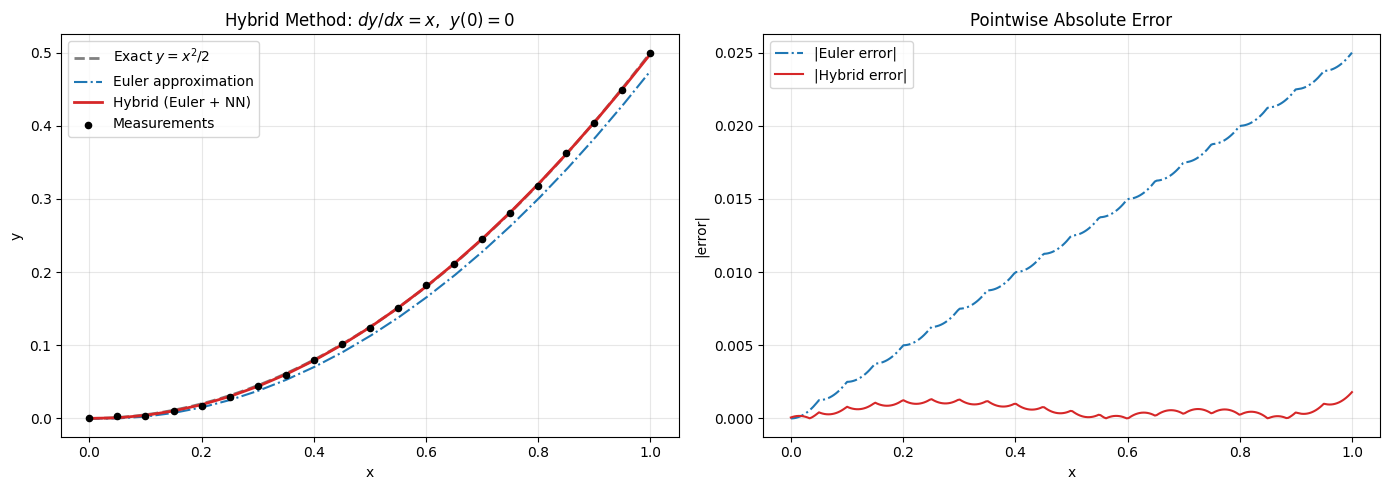

In [ ]:
# ── Build hybrid solution on test grid ────────────────────────────────────
y_eu_test_jnp  = jnp.array(y_eu_test)                              # Euler on test grid
h_correction   = jax.vmap(h_single, in_axes=(None, 0))(            # correction
                     params_corr, x_test).reshape(-1, 1)
y_hybrid       = y_eu_test_jnp + h_correction                      # final answer

# ── Error metrics ─────────────────────────────────────────────────────────
mse_euler  = float(jnp.mean((y_eu_test_jnp - y_exact_test)**2))
mse_hybrid = float(jnp.mean((y_hybrid       - y_exact_test)**2))
rel_l1     = float(jnp.sum(jnp.abs(y_hybrid - y_exact_test)) /
                   jnp.sum(jnp.abs(y_exact_test)))
print(f'Euler  MSE : {mse_euler:.6f}')
print(f'Hybrid MSE : {mse_hybrid:.6f}')
print(f'Hybrid Relative L1 error: {rel_l1:.4e}')

# ── Figure 1: solution comparison ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(x_test, y_exact_test,   label='Exact $y=x^2/2$',        color='grey',      linestyle='--', lw=2)
ax.plot(x_test, y_eu_test_jnp,  label='Euler approximation',    color='tab:blue',  linestyle='-.',  lw=1.5)
ax.plot(x_test, y_hybrid,       label='Hybrid (Euler + NN)',     color='tab:red',   lw=2)
ax.scatter(np.array(x_meas), np.array(y_star),
           label='Measurements', color='black', zorder=5, s=20)
ax.set_title('Hybrid Method: $dy/dx=x$,  $y(0)=0$')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(); ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(x_test, jnp.abs(y_eu_test_jnp - y_exact_test), label='|Euler error|',  color='tab:blue',  linestyle='-.')
ax2.plot(x_test, jnp.abs(y_hybrid       - y_exact_test), label='|Hybrid error|', color='tab:red')
ax2.set_title('Pointwise Absolute Error')
ax2.set_xlabel('x'); ax2.set_ylabel('|error|')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

---
## Inverse Problem: Estimate $\alpha$ in $dy/dx = \alpha x$

We now jointly train:
- The correction network $h_\theta$ (same hybrid approach)
- An unknown scalar $\alpha$ (the coefficient of $x$)

The hybrid trial solution is still $y(x) = y_{\text{Eu}}(x) + h_\theta(x)$.  
Its derivative is $y'(x) \approx \frac{d}{dx}[y_{\text{Eu}}(x)] + h'_\theta(x) = x + h'_\theta(x)$.  

**Combined loss:**
$$\mathcal{L}(\theta, \alpha) =
\underbrace{\frac{1}{n}\sum_k (r_k - h_\theta(x_k))^2 + h_\theta(0)^2}_{\text{residual fit + IC}}
+\;\lambda_{\text{phy}}\underbrace{\frac{1}{m}\sum_j\bigl(x_j + h'_\theta(x_j) - \alpha x_j\bigr)^2}_{\text{ODE residual}}
+\;\lambda_{\text{data}}\underbrace{\frac{1}{p}\sum_i(y_{\text{Eu}}(x_i)+h_\theta(x_i)-y^*_i)^2}_{\text{data fit}}$$

True value: $\alpha = 1.0$.

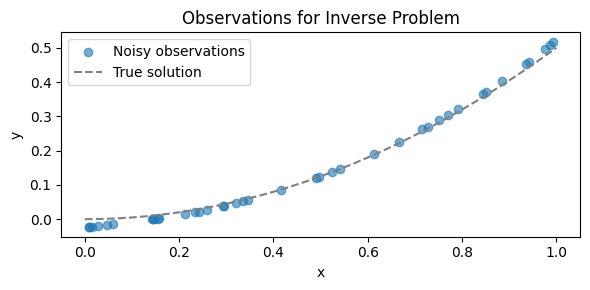

In [ ]:
# ── Noisy observations (40 random points) ────────────────────────────────
key, subkey = jax.random.split(key)
x_obs = jax.random.uniform(subkey, (40, 1))                        # random x in [0,1]
y_obs = exact_solution(x_obs) + 0.01 * jax.random.normal(subkey, (40, 1))

# Physics collocation points (dense grid for ODE residual)
x_phys = jnp.linspace(0.0, 1.0, 50).reshape(-1, 1)

plt.figure(figsize=(6, 3))
plt.scatter(np.array(x_obs), np.array(y_obs), label='Noisy observations', alpha=0.6, color='tab:blue')
plt.plot(np.linspace(0,1,200), exact_solution(np.linspace(0,1,200)),
         label='True solution', color='grey', linestyle='--')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Observations for Inverse Problem')
plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
# ── Euler derivative at any x: d/dx[y_Eu] = x  (the RHS of the ODE) ──────
# For the ODE residual we need y'(x) = Euler_deriv(x) + h'_theta(x)
# Euler_deriv(x) = F(x,y) = x  (the RHS we integrated)

def euler_deriv(x_scalar):
    """Derivative of y_Eu at x (equals the ODE RHS = x)."""
    return x_scalar                                                 # dy_Eu/dx = x


def inverse_loss(params_alpha, x_meas, residuals, x_obs, y_obs, x_phys,
                 lam_phy=1.0, lam_data=10.0):
    """
    params_alpha : (network_params, alpha)  – joint learnable state
    x_meas       : Euler grid points         (n,1)
    residuals    : y* - y_Eu at grid         (n,1)
    x_obs        : random observation x      (p,1)
    y_obs        : noisy y observations      (p,1)
    x_phys       : collocation x for ODE     (m,1)
    """
    params, alpha = params_alpha

    # ── 1. Residual fit + IC (same as forward problem) ──────────────────
    h_at_meas = jax.vmap(h_single, in_axes=(None, 0))(params, x_meas).reshape(-1)
    loss_fit  = jnp.mean((residuals.squeeze() - h_at_meas)**2)
    loss_ic   = h_single(params, jnp.array(0.0))**2

    # ── 2. ODE physics residual: y'(x) - alpha*x = 0 ───────────────────
    # y'(x) = euler_deriv(x) + h'_theta(x)  where h' is via jax.grad
    def h_prime(x_scalar):
        return jax.grad(h_single, argnums=1)(params, x_scalar)

    def ode_residual_single(x_scalar):
        yprime = euler_deriv(x_scalar) + h_prime(x_scalar)         # y'(x)
        return (yprime - alpha * x_scalar)**2

    loss_phy = jnp.mean(
        jax.vmap(ode_residual_single)(x_phys.squeeze()))

    # ── 3. Data fit: y_hybrid(x_obs) = y_Eu(x_obs) + h(x_obs) vs y_obs ─
    y_eu_obs  = jnp.array(y_euler_at(x_obs)).squeeze()             # Euler at obs pts
    h_at_obs  = jax.vmap(h_single, in_axes=(None, 0))(params, x_obs).reshape(-1)
    y_hyb_obs = y_eu_obs + h_at_obs
    loss_data = jnp.mean((y_hyb_obs - y_obs.squeeze())**2)

    return loss_fit + loss_ic + lam_phy * loss_phy + lam_data * loss_data


@partial(jax.jit, static_argnums=(1,))
def inverse_step(opt_state, optimiser, params_alpha,
                 x_meas, residuals, x_obs, y_obs, x_phys):
    loss, grads = jax.value_and_grad(inverse_loss)(
        params_alpha, x_meas, residuals, x_obs, y_obs, x_phys)
    updates, opt_state = optimiser.update(grads, opt_state, params_alpha)
    params_alpha = optax.apply_updates(params_alpha, updates)
    return loss, opt_state, params_alpha

In [ ]:
def y_euler_at(x_jnp):
    """Evaluate y_Eu at arbitrary JAX array x by linear interpolation."""
    # Use jnp.interp for JAX compatibility
    return jnp.interp(x_jnp.ravel(), x_euler_np, y_euler_np).reshape(-1, 1)

# ── Initialise joint (params, alpha) ─────────────────────────────────────
key, subkey   = jax.random.split(key)
params_inv    = network.init_parameters(subkey, [1, 32, 32, 1])
alpha_init    = jnp.array(0.0)                                     # initial guess
params_alpha  = (params_inv, alpha_init)

optimiser_inv = optax.adam(learning_rate=1e-3)
opt_state_inv = optimiser_inv.init(params_alpha)

N_INV    = 15001
alphas   = []
inv_loss_history = []

start = time.time()
for i in range(N_INV):
    loss_val, opt_state_inv, params_alpha = inverse_step(
        opt_state_inv, optimiser_inv, params_alpha,
        x_meas, residuals, x_obs, y_obs, x_phys)

    alphas.append(float(params_alpha[1]))
    inv_loss_history.append(float(loss_val))

    if i % 3000 == 0:
        print(f'Step {i:5d} | Loss: {float(loss_val):.4e} | Alpha: {float(params_alpha[1]):.4f}')

print(f'\nTraining time : {time.time()-start:.2f} s')
print(f'Estimated alpha: {float(params_alpha[1]):.4f}  (true = 1.0)')

Step     0 | Loss: 5.3072e-01 | Alpha: 0.0010
Step  3000 | Loss: 4.7845e-04 | Alpha: 1.0985
Step  6000 | Loss: 4.6314e-04 | Alpha: 1.1033
Step  9000 | Loss: 4.6295e-04 | Alpha: 1.1033
Step 12000 | Loss: 4.6289e-04 | Alpha: 1.1033
Step 15000 | Loss: 4.6288e-04 | Alpha: 1.1032

Training time : 10.16 s
Estimated alpha: 1.1032  (true = 1.0)


Inverse hybrid MSE : 0.000080
Recovered alpha    : 1.1032  (true = 1.0)


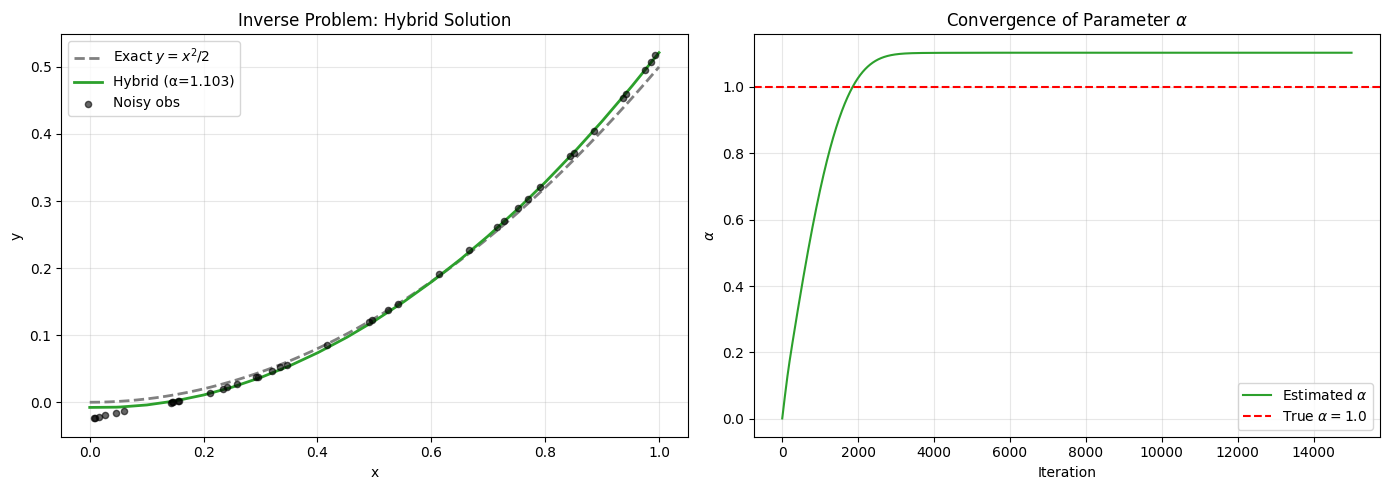

In [29]:
# ── Build hybrid solution with inverse-trained network ────────────────────
params_inv_final = params_alpha[0]
alpha_final      = float(params_alpha[1])

h_inv       = jax.vmap(h_single, in_axes=(None, 0))(
                  params_inv_final, x_test).reshape(-1, 1)
y_hyb_inv   = jnp.array(y_eu_test) + h_inv

mse_inv = float(jnp.mean((y_hyb_inv - y_exact_test)**2))
print(f'Inverse hybrid MSE : {mse_inv:.6f}')
print(f'Recovered alpha    : {alpha_final:.4f}  (true = 1.0)')

# ── Figure A: solution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(x_test, y_exact_test, label='Exact $y=x^2/2$',          color='grey',     linestyle='--', lw=2)
ax.plot(x_test, y_hyb_inv,    label=f'Hybrid (α={alpha_final:.3f})', color='tab:green', lw=2)
ax.scatter(np.array(x_obs), np.array(y_obs),
           label='Noisy obs', color='black', zorder=5, s=20, alpha=0.6)
ax.set_title('Inverse Problem: Hybrid Solution')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(); ax.grid(True, alpha=0.3)

# ── Figure B: alpha convergence ───────────────────────────────────────────
ax2 = axes[1]
ax2.plot(alphas, color='tab:green', label='Estimated $\\alpha$')
ax2.axhline(y=1.0, color='red', linestyle='--', lw=1.5, label='True $\\alpha=1.0$')
ax2.set_title('Convergence of Parameter $\\alpha$')
ax2.set_xlabel('Iteration'); ax2.set_ylabel('$\\alpha$')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()